In [23]:
import numpy as np
import matplotlib.pyplot as plt
import io
import matplotlib.colors as mcolors
import requests
import xarray as xr

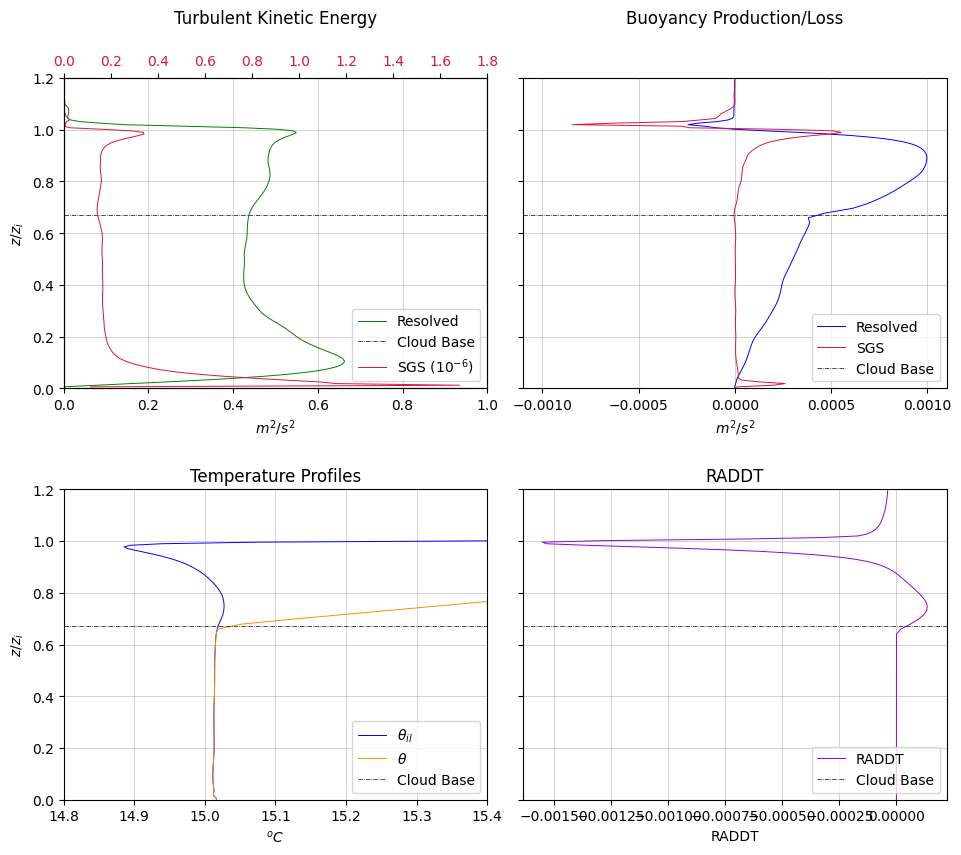

In [40]:
# --- Cloud base (last time steo) ---
zi=833.5
c_base=560/zi

# --- Buoyancy/TKE data ---
url4="https://raw.githubusercontent.com/ChrisPhys97/Bachelor-Thesis/refs/heads/main/data/Buoyancy_TKE_data.nc"
response=requests.get(url4)
data=response.content
bf=xr.open_dataset(io.BytesIO(data),engine="h5netcdf")

fig,ax=plt.subplots(2,2,figsize=(9.5,8.5),constrained_layout={'hspace': 0.07, 'h_pad': 0.07})
ax[1,0].plot(bf.PTIL.values-273.15,bf.z.values/zi,linewidth=0.7,color="b",label=r"$\theta_{il}$")
ax[1,0].plot(bf.PT.values-273.15,bf.z.values/zi,color="darkorange",linewidth=0.7,label=r"$\theta$")
ax[1,1].plot(bf.RADDT.values,bf.z.values/zi,color="darkviolet",linewidth=0.7,label="RADDT")
ax[0,1].set_yticklabels([])
ax[0,1].plot(bf.BFRES.values,bf.z.values/zi,linewidth=0.7,color="b",label="Resolved")
ax[0,1].plot(bf.BFSGS.values,bf.z.values/zi,linewidth=0.7,color="crimson",label="SGS")
ax[0,0].plot(bf.TKERES.values, bf.z.values/zi, linewidth=0.7, color="g", label="Resolved")
ax[1,1].set_yticklabels([])

ax_twin = ax[0,0].twiny()
ax_twin.plot(bf.TKESGS.values/1e-6, bf.z.values/zi, linewidth=0.7, color="crimson", label="SGS $(10^{-6})$")
ax_twin.tick_params(axis='x', labelcolor='crimson')
xlabels=["$m^2/s^2$","$m^2/s^2$","${}^oC$","RADDT"]
subplot_titles = ["Turbulent Kinetic Energy", "Buoyancy Production/Loss","Temperature Profiles", "RADDT"]
i=0
for a_single_ax in ax.flat:
  a_single_ax.set_ylim([0,1.2])
  a_single_ax.set_xlabel(xlabels[i])
  if i < 2:
      a_single_ax.set_title(subplot_titles[i], y=1.15) # Keep higher y for top row
  else:
      a_single_ax.set_title(subplot_titles[i])
  a_single_ax.grid(True,linewidth=0.5,alpha=0.8)
  a_single_ax.axhline(y=c_base,linewidth=0.5,color="k",label="Cloud Base",linestyle="-.")
  if a_single_ax != ax[0,0]:
      a_single_ax.legend(loc="lower right")
  i+=1
handles1, labels1 = ax[0,0].get_legend_handles_labels()
handles2, labels2 = ax_twin.get_legend_handles_labels()
ax_twin.set_xlim([0,1.8])
ax[0,0].legend(handles1 + handles2, labels1 + labels2, loc='lower right')
ax[0,0].set_xlim([0,1])
ax[1,0].set_xlim([14.8,15.4])
#ax[1,1].set_xlim([-0.03,0.03])
ax[0,1].set_xlim([-0.0011,0.0011])
ax[0,1].set_xticks([-0.001, -0.0005, 0, 0.0005, 0.001])
ax[0,0].set_ylabel("$z/z_i$")
ax[1,0].set_ylabel("$z/z_i$")
plt.show()